# Multi-task Learning: AI vs Real + Category Classification

This notebook is adjusted to match the team preprocessing plan from the meeting:

- Use the same dataset inventory style as the preprocessing notebook
- Use **stratified train / validation / test split** based on `label + category`
- Use the same core preprocessing idea: `Resize(256) -> CenterCrop(224)`
- Use similar training augmentation: horizontal flip + moderate color jitter
- Train a **multi-task model** with two heads:
  - `auth_output`: AI vs Real
  - `cat_output`: category classification
- Try both imbalance strategies:
  1. **Class weights / weighted loss** through per-sample weights
  2. **Weighted random sampler** using a balanced `tf.data` sampler
- Report **AI recall** as a key metric

The main model is a shared pretrained EfficientNetB0 backbone with two output heads.

## 1. Setup

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    f1_score,
    recall_score,
    accuracy_score,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMAGE_SIZE = 224
RESIZE_SIZE = 256
BATCH_SIZE = 32
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15
AUTOTUNE = tf.data.AUTOTUNE

print("GPU available:", bool(tf.config.list_physical_devices("GPU")))

TensorFlow version: 2.20.0
GPU available: True


## 2. Download Dataset with KaggleHub

In [2]:
# If kagglehub is not installed, uncomment and run the next line first.
# !pip install kagglehub

import kagglehub

raw_path = kagglehub.dataset_download("rhythmghai/ai-vs-real-images-dataset")
DATASET_PATH = Path(raw_path)

print("Path to dataset files:", DATASET_PATH)
print("Dataset path exists:", DATASET_PATH.exists())

print("\nTop-level contents:")
for p in sorted(DATASET_PATH.iterdir()):
    print(" -", p.name)

Using Colab cache for faster access to the 'ai-vs-real-images-dataset' dataset.
Path to dataset files: /kaggle/input/ai-vs-real-images-dataset
Dataset path exists: True

Top-level contents:
 - Ai_generated_dataset
 - real_dataset


## 3. Build Image Inventory

This follows the same logic as the team preprocessing notebook:

```text
real_dataset/category/image.jpg       -> Real
Ai_generated_dataset/category/image.jpg -> AI
```

The code also includes a flexible fallback parser in case the downloaded folder structure is slightly different.

In [3]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

LABEL_MAP = {
    "real_dataset": "Real",
    "Ai_generated_dataset": "AI",
    "ai_generated_dataset": "AI",
    "AI_generated_dataset": "AI",
}
LABEL_TO_IDX = {"Real": 0, "AI": 1}  # 1 = positive class, AI


def normalize_token(s):
    return str(s).lower().replace("-", "_").replace(" ", "_")


def infer_labels_flexible(img_path, root):
    """Fallback parser for cases where folder names are not exactly real_dataset / Ai_generated_dataset."""
    rel_parts = img_path.relative_to(root).parts
    norm_parts = [normalize_token(p) for p in rel_parts]

    authenticity = None
    auth_idx = None
    for i, token in enumerate(norm_parts[:-1]):
        if token in {"ai", "ai_generated", "aigenerated", "synthetic", "fake"} or "generated" in token or "fake" in token:
            authenticity = "AI"
            auth_idx = i
            break
        if token in {"real", "real_dataset", "natural", "authentic", "photo", "photographic"} or token.startswith("real"):
            authenticity = "Real"
            auth_idx = i
            break

    if authenticity is None:
        return None, None

    if auth_idx is not None and auth_idx + 1 < len(rel_parts) - 1:
        category = rel_parts[auth_idx + 1]
    elif auth_idx is not None and auth_idx - 1 >= 0:
        category = rel_parts[auth_idx - 1]
    else:
        category = "unknown"

    return authenticity, category


records = []

# Preferred parser: same as preprocessing.ipynb
for label_folder in sorted(DATASET_PATH.iterdir()):
    if not label_folder.is_dir():
        continue

    label = LABEL_MAP.get(label_folder.name)
    if label is None:
        continue

    for category_folder in sorted(label_folder.iterdir()):
        if not category_folder.is_dir():
            continue
        for img_path in sorted(category_folder.iterdir()):
            if img_path.suffix.lower() in IMAGE_EXTENSIONS:
                records.append({
                    "filepath": str(img_path),
                    "label": label,
                    "authenticity": label,
                    "auth_label": LABEL_TO_IDX[label],
                    "category": category_folder.name,
                })

# Fallback parser if preferred parser found nothing
if len(records) == 0:
    print("Preferred parser found no images. Using flexible recursive parser instead.")
    for img_path in sorted(DATASET_PATH.rglob("*")):
        if img_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue
        authenticity, category = infer_labels_flexible(img_path, DATASET_PATH)
        if authenticity is None:
            continue
        records.append({
            "filepath": str(img_path),
            "label": authenticity,
            "authenticity": authenticity,
            "auth_label": LABEL_TO_IDX[authenticity],
            "category": category,
        })


df = pd.DataFrame(records)

if df.empty:
    raise ValueError("No images were found. Please inspect DATASET_PATH and update the parser.")

print(f"Total images: {len(df)}")
print("\nClass counts:")
print(df["label"].value_counts().to_string())
print("\nCategory counts:")
print(df["category"].value_counts().to_string())
print("\nCategory × label distribution:")
print(pd.crosstab(df["category"], df["label"]))

df.head()

Total images: 995

Class counts:
label
Real    745
AI      250

Category counts:
category
city       200
nature     200
food       200
animals    198
people     197

Category × label distribution:
label     AI  Real
category          
animals   50   148
city      50   150
food      50   150
nature    50   150
people    50   147


,filepath,label,authenticity,auth_label,category
0,/kaggle/input/ai-vs-real-images-dataset/Ai_gen...,AI,AI,1,animals
1,/kaggle/input/ai-vs-real-images-dataset/Ai_gen...,AI,AI,1,animals
2,/kaggle/input/ai-vs-real-images-dataset/Ai_gen...,AI,AI,1,animals
3,/kaggle/input/ai-vs-real-images-dataset/Ai_gen...,AI,AI,1,animals
4,/kaggle/input/ai-vs-real-images-dataset/Ai_gen...,AI,AI,1,animals


## 4. Encode Category Labels

In [4]:
category_encoder = LabelEncoder()
df["cat_label"] = category_encoder.fit_transform(df["category"])
num_categories = len(category_encoder.classes_)

print("Category classes:", list(category_encoder.classes_))
print("Number of categories:", num_categories)

df.head()

Category classes: ['animals', 'city', 'food', 'nature', 'people']
Number of categories: 5


,filepath,label,authenticity,auth_label,category,cat_label
0,/kaggle/input/ai-vs-real-images-dataset/Ai_gen...,AI,AI,1,animals,0
1,/kaggle/input/ai-vs-real-images-dataset/Ai_gen...,AI,AI,1,animals,0
2,/kaggle/input/ai-vs-real-images-dataset/Ai_gen...,AI,AI,1,animals,0
3,/kaggle/input/ai-vs-real-images-dataset/Ai_gen...,AI,AI,1,animals,0
4,/kaggle/input/ai-vs-real-images-dataset/Ai_gen...,AI,AI,1,animals,0


## 5. Stratified Train / Validation / Test Split

We stratify using `label + category`, so each split keeps a similar AI/Real ratio and category distribution.

- Train: 70%
- Validation: 15%
- Test: 15%

In [5]:
df["strat_key"] = df["label"] + "_" + df["category"]

# If any label-category pair has too few samples, fall back to authenticity-only stratification.
strat_counts = df["strat_key"].value_counts()
stratify_col = "strat_key" if strat_counts.min() >= 2 else "label"
print("Using stratification column:", stratify_col)

# Step 1: split off test set
trainval_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    stratify=df[stratify_col],
    random_state=SEED,
)

# Step 2: split train and validation
val_fraction_of_trainval = VAL_SIZE / (TRAIN_SIZE + VAL_SIZE)
trainval_strat_counts = trainval_df[stratify_col].value_counts()
if trainval_strat_counts.min() >= 2:
    trainval_stratify = trainval_df[stratify_col]
else:
    trainval_stratify = trainval_df["label"]

train_df, val_df = train_test_split(
    trainval_df,
    test_size=val_fraction_of_trainval,
    stratify=trainval_stratify,
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Split Summary:")
print(f"  Train: {len(train_df):>4} images ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Val  : {len(val_df):>4} images ({len(val_df)/len(df)*100:.1f}%)")
print(f"  Test : {len(test_df):>4} images ({len(test_df)/len(df)*100:.1f}%)")

print("\nClass distribution in each split:")
for name, split_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    counts = split_df["label"].value_counts()
    real_count = counts.get("Real", 0)
    ai_count = counts.get("AI", 0)
    print(f"  {name}: Real={real_count} ({real_count/len(split_df)*100:.1f}%) | AI={ai_count} ({ai_count/len(split_df)*100:.1f}%)")

print("\nTrain category × label distribution:")
print(pd.crosstab(train_df["category"], train_df["label"]))

Using stratification column: strat_key
Split Summary:
  Train:  695 images (69.8%)
  Val  :  150 images (15.1%)
  Test :  150 images (15.1%)

Class distribution in each split:
  Train: Real=520 (74.8%) | AI=175 (25.2%)
  Val: Real=112 (74.7%) | AI=38 (25.3%)
  Test: Real=113 (75.3%) | AI=37 (24.7%)

Train category × label distribution:
label     AI  Real
category          
animals   35   104
city      35   104
food      35   105
nature    35   104
people    35   103


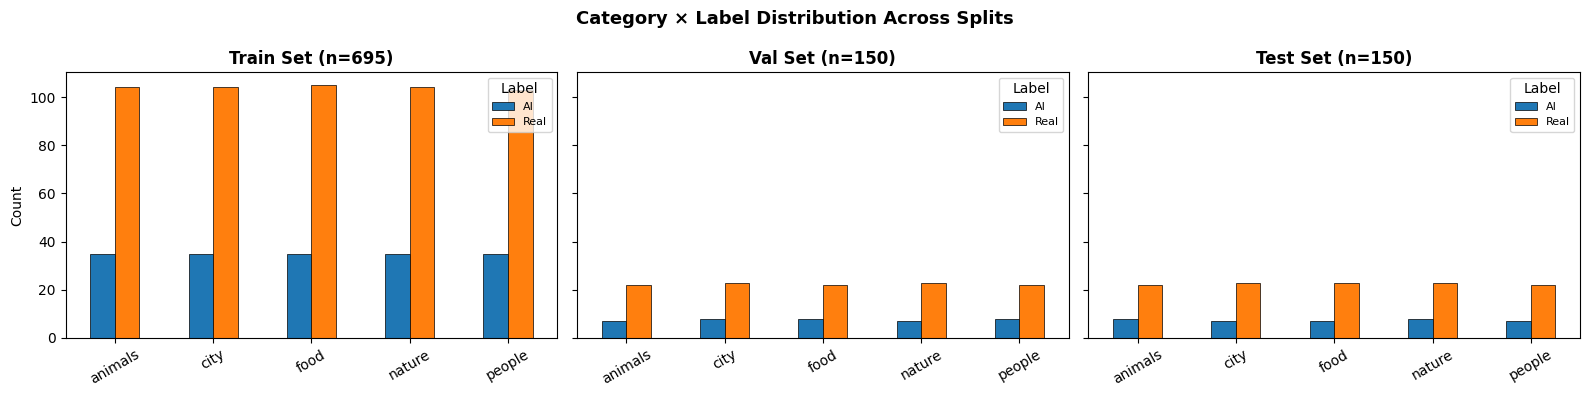

In [6]:
# Visual check: category balance across splits
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, (name, split_df) in zip(axes, [("Train", train_df), ("Val", val_df), ("Test", test_df)]):
    pivot = split_df.groupby(["category", "label"]).size().unstack(fill_value=0)
    pivot.plot(kind="bar", ax=ax, edgecolor="black", linewidth=0.5)
    ax.set_title(f"{name} Set (n={len(split_df)})", fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="Label", fontsize=8)
    if ax == axes[0]:
        ax.set_ylabel("Count")

plt.suptitle("Category × Label Distribution Across Splits", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. TensorFlow Preprocessing and Augmentation

This matches the team preprocessing idea:

- Resize the shortest side to 256
- Center crop to 224 × 224
- Training only: horizontal flip + moderate color jitter
- Validation/test: no augmentation

Note: `tf.keras.applications.EfficientNetB0` includes its own input preprocessing, so we keep image values in the 0–255 range instead of manually applying PyTorch ImageNet normalization.

In [7]:
def resize_shortest_side(image, target_size=RESIZE_SIZE):
    shape = tf.shape(image)
    h = tf.cast(shape[0], tf.float32)
    w = tf.cast(shape[1], tf.float32)
    scale = tf.cast(target_size, tf.float32) / tf.minimum(h, w)
    new_h = tf.cast(tf.round(h * scale), tf.int32)
    new_w = tf.cast(tf.round(w * scale), tf.int32)
    return tf.image.resize(image, [new_h, new_w])


def center_crop_224(image):
    return tf.image.resize_with_crop_or_pad(image, IMAGE_SIZE, IMAGE_SIZE)


def color_jitter(image):
    # Similar to torchvision ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05).
    # These TensorFlow ops are safest on the 0-1 scale, then we convert back to 0-255
    # because EfficientNetB0 includes its own preprocessing layer.
    image = tf.clip_by_value(image / 255.0, 0.0, 1.0)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.9, upper=1.1)
    image = tf.image.random_hue(image, max_delta=0.05)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image * 255.0


def load_image_base(filepath, auth_label, cat_label, training=False):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.cast(image, tf.float32)

    image = resize_shortest_side(image, RESIZE_SIZE)
    image = center_crop_224(image)

    if training:
        image = tf.image.random_flip_left_right(image, seed=SEED)
        image = color_jitter(image)

    auth_label = tf.cast(auth_label, tf.float32)
    cat_label = tf.cast(cat_label, tf.int32)
    labels = (auth_label, cat_label)
    return image, labels


def make_dataset(dataframe, training=False, shuffle=False, batch=True):
    ds = tf.data.Dataset.from_tensor_slices((
        dataframe["filepath"].values,
        dataframe["auth_label"].values,
        dataframe["cat_label"].values,
    ))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda fp, a, c: load_image_base(fp, a, c, training=training), num_parallel_calls=AUTOTUNE)
    if batch:
        ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds_natural = make_dataset(train_df, training=True, shuffle=True, batch=True)
val_ds = make_dataset(val_df, training=False, shuffle=False, batch=True)
test_ds = make_dataset(test_df, training=False, shuffle=False, batch=True)

print("Natural train batches:", len(train_ds_natural))
print("Validation batches:", len(val_ds))
print("Test batches:", len(test_ds))

Natural train batches: 22
Validation batches: 5
Test batches: 5


### Sanity Check: Visualize a Training Batch

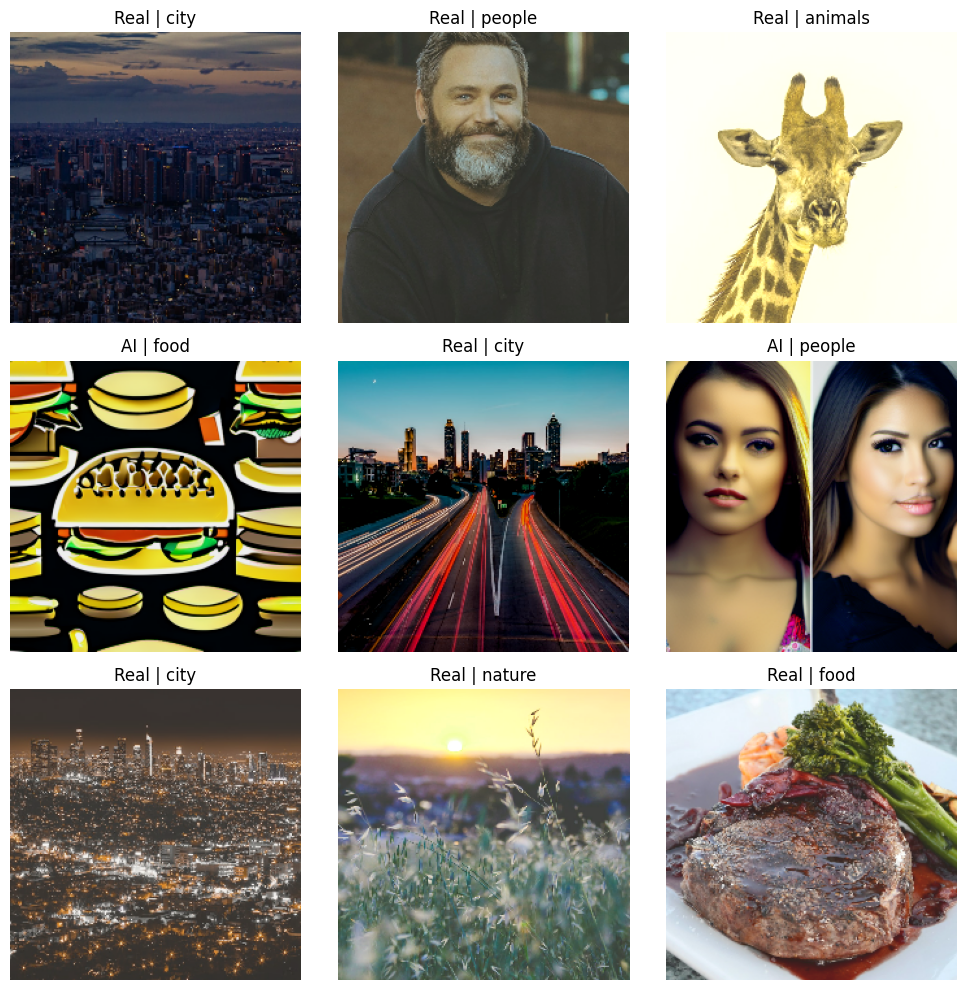

In [8]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds_natural.take(1):
    auth_labels_batch, cat_labels_batch = labels
    for i in range(min(9, images.shape[0])):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        auth_name = "AI" if int(auth_labels_batch[i].numpy()) == 1 else "Real"
        cat_name = category_encoder.inverse_transform([int(cat_labels_batch[i].numpy())])[0]
        plt.title(f"{auth_name} | {cat_name}")
        plt.axis("off")
plt.tight_layout()
plt.show()

## 7. Imbalance Strategy A: Class Weights / Weighted Loss

For Keras multi-output models, we use **sample weights**. This has the same idea as loss class weights:

- mistakes on the minority AI class receive a larger penalty
- category imbalance can also receive separate weights

The sample weights are computed from the training set only.

In [9]:
def make_class_weight_dict(labels):
    classes = np.unique(labels)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=labels,
    )
    return {int(cls): float(w) for cls, w in zip(classes, weights)}


auth_class_weights = make_class_weight_dict(train_df["auth_label"].values)
cat_class_weights = make_class_weight_dict(train_df["cat_label"].values)

print("Authenticity class weights:")
for k, v in auth_class_weights.items():
    print(f"  {k} ({'AI' if k == 1 else 'Real'}): {v:.4f}")

print("\nCategory class weights:")
for k, v in cat_class_weights.items():
    print(f"  {k} ({category_encoder.inverse_transform([k])[0]}): {v:.4f}")

Authenticity class weights:
  0 (Real): 0.6683
  1 (AI): 1.9857

Category class weights:
  0 (animals): 1.0000
  1 (city): 1.0000
  2 (food): 0.9929
  3 (nature): 1.0000
  4 (people): 1.0072


In [10]:
auth_weight_tensor = tf.constant(
    [auth_class_weights.get(0, 1.0), auth_class_weights.get(1, 1.0)],
    dtype=tf.float32,
)
cat_weight_tensor = tf.constant(
    [cat_class_weights.get(i, 1.0) for i in range(num_categories)],
    dtype=tf.float32,
)


def add_sample_weights(image, labels):
    auth_label, cat_label = labels
    auth_idx = tf.cast(auth_label, tf.int32)
    cat_idx = tf.cast(cat_label, tf.int32)

    auth_weight = tf.gather(auth_weight_tensor, auth_idx)
    cat_weight = tf.gather(cat_weight_tensor, cat_idx)

    sample_weights = (auth_weight, cat_weight)
    return image, labels, sample_weights


weighted_train_ds = train_ds_natural.map(add_sample_weights, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

for batch in weighted_train_ds.take(1):
    images, labels, sample_weights = batch
    print("Image batch shape:", images.shape)
    print("Auth label shape:", labels[0].shape)
    print("Category label shape:", labels[1].shape)
    print("Auth sample weight shape:", sample_weights[0].shape)
    print("Category sample weight shape:", sample_weights[1].shape)

Image batch shape: (32, 224, 224, 3)
Auth label shape: (32,)
Category label shape: (32,)
Auth sample weight shape: (32,)
Category sample weight shape: (32,)


## 8. Imbalance Strategy B: Weighted Random Sampler

Keras does not have PyTorch's `WeightedRandomSampler`, so we implement the same idea with `tf.data.Dataset.sample_from_datasets`.

This creates a balanced stream of training examples:

- 50% Real
- 50% AI

This sampler is based on the authenticity label. The category label is still preserved for the second output head.

In [11]:
def make_unbatched_dataset(dataframe, training=True, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((
        dataframe["filepath"].values,
        dataframe["auth_label"].values,
        dataframe["cat_label"].values,
    ))
    if shuffle:
        ds = ds.shuffle(buffer_size=max(len(dataframe), 1), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda fp, a, c: load_image_base(fp, a, c, training=training), num_parallel_calls=AUTOTUNE)
    return ds

real_train_df = train_df[train_df["auth_label"] == 0].reset_index(drop=True)
ai_train_df = train_df[train_df["auth_label"] == 1].reset_index(drop=True)

if len(real_train_df) == 0 or len(ai_train_df) == 0:
    raise ValueError("Both Real and AI classes are required to build the balanced sampler.")

real_ds = make_unbatched_dataset(real_train_df, training=True, shuffle=True).repeat()
ai_ds = make_unbatched_dataset(ai_train_df, training=True, shuffle=True).repeat()

balanced_train_ds = tf.data.Dataset.sample_from_datasets(
    [real_ds, ai_ds],
    weights=[0.5, 0.5],
    seed=SEED,
)
balanced_train_ds = balanced_train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

steps_per_epoch_balanced = int(np.ceil(len(train_df) / BATCH_SIZE))

print("Real train images:", len(real_train_df))
print("AI train images:", len(ai_train_df))
print("Balanced sampler steps per epoch:", steps_per_epoch_balanced)

# Sanity check: AI and Real should appear roughly balanced in one batch.
for images, labels in balanced_train_ds.take(1):
    auth_labels_batch = labels[0].numpy().astype(int)
    print("One balanced batch counts:", dict(zip(*np.unique(auth_labels_batch, return_counts=True))))

Real train images: 520
AI train images: 175
Balanced sampler steps per epoch: 22
One balanced batch counts: {np.int64(0): np.int64(15), np.int64(1): np.int64(17)}


## 9. Build Multi-task EfficientNetB0 Model

In [12]:
def build_multitask_model(num_categories, img_size=IMAGE_SIZE):
    inputs = keras.Input(shape=(img_size, img_size, 3), name="image_input")

    # EfficientNetB0 includes built-in preprocessing for image values in the 0-255 range.
    backbone = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_tensor=inputs,
    )
    backbone.trainable = False

    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(backbone.output)
    x = layers.Dropout(0.30, name="shared_dropout_1")(x)
    x = layers.Dense(256, activation="relu", name="shared_dense")(x)
    x = layers.Dropout(0.30, name="shared_dropout_2")(x)

    auth_output = layers.Dense(1, activation="sigmoid", name="auth_output")(x)
    cat_output = layers.Dense(num_categories, activation="softmax", name="cat_output")(x)

    model = keras.Model(
        inputs=inputs,
        outputs=[auth_output, cat_output],
        name="multitask_efficientnetb0",
    )
    return model, backbone


def compile_multitask_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=[
            keras.losses.BinaryCrossentropy(),
            keras.losses.SparseCategoricalCrossentropy(),
        ],
        loss_weights=[1.0, 1.0],
        metrics=[
            [
                keras.metrics.BinaryAccuracy(name="accuracy"),
                keras.metrics.Precision(name="precision"),
                keras.metrics.Recall(name="ai_recall"),
                keras.metrics.AUC(name="auc"),
            ],
            [
                keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
            ],
        ],
    )
    return model

## 10. Training Helper Functions

In [13]:
EPOCHS_HEAD = 15
EPOCHS_FINE = 5


def get_callbacks(model_name):
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=2,
            min_lr=1e-6,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=f"{model_name}.keras",
            monitor="val_loss",
            save_best_only=True,
        ),
    ]


def train_model(strategy_name, train_data, use_steps_per_epoch=False):
    print("=" * 80)
    print(f"Training strategy: {strategy_name}")
    print("=" * 80)

    model, backbone = build_multitask_model(num_categories)
    compile_multitask_model(model, learning_rate=1e-3)

    fit_kwargs = {}
    if use_steps_per_epoch:
        fit_kwargs["steps_per_epoch"] = steps_per_epoch_balanced

    history_head = model.fit(
        train_data,
        validation_data=val_ds,
        epochs=EPOCHS_HEAD,
        callbacks=get_callbacks(f"multitask_{strategy_name}_head"),
        **fit_kwargs,
    )

    # Fine-tune last 25% of EfficientNet layers.
    backbone.trainable = True
    fine_tune_at = int(len(backbone.layers) * 0.75)
    for layer in backbone.layers[:fine_tune_at]:
        layer.trainable = False

    compile_multitask_model(model, learning_rate=1e-5)

    history_fine = model.fit(
        train_data,
        validation_data=val_ds,
        epochs=EPOCHS_FINE,
        callbacks=get_callbacks(f"multitask_{strategy_name}_finetuned"),
        **fit_kwargs,
    )

    return model, [history_head, history_fine]

## 11. Train Both Imbalance Strategies

This follows the meeting note: try both imbalance-handling approaches.

- `loss_weights`: class weights through weighted loss / sample weights
- `weighted_sampler`: balanced random sampler

If training time is limited, set one of the flags below to `False`.

In [14]:
RUN_LOSS_WEIGHTS = True
RUN_WEIGHTED_SAMPLER = True

models = {}
histories = {}

if RUN_LOSS_WEIGHTS:
    models["loss_weights"], histories["loss_weights"] = train_model(
        strategy_name="loss_weights",
        train_data=weighted_train_ds,
        use_steps_per_epoch=False,
    )

if RUN_WEIGHTED_SAMPLER:
    models["weighted_sampler"], histories["weighted_sampler"] = train_model(
        strategy_name="weighted_sampler",
        train_data=balanced_train_ds,
        use_steps_per_epoch=True,
    )

print("Finished training:", list(models.keys()))

Training strategy: loss_weights
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - auth_output_accuracy: 0.7381 - auth_output_ai_recall: 0.8857 - auth_output_auc: 0.8930 - auth_output_loss: 0.4487 - auth_output_precision: 0.4890 - cat_output_accuracy: 0.7281 - cat_output_loss: 0.8039 - loss: 1.2597 - val_auth_output_accuracy: 0.9467 - val_auth_output_ai_recall: 0.9474 - val_auth_output_auc: 0.9907 - val_auth_output_loss: 0.2246 - val_auth_output_precision: 0.8571 - val_cat_output_accuracy: 0.9333 - val_cat_output_loss: 0.2554 - val_loss: 0.4872 - learning_rate: 0.0010
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 599ms/step - auth_output_accuracy: 0.9266 - auth_output_ai_recall: 0.9429 - auth_output_auc: 0.9832 - auth_output_loss: 0.2082 - auth_output_precision: 0.8010 - cat_output_accuracy: 0.9496 - cat_output_loss: 0.2167 - loss: 0.4254 - val_auth_output_accuracy: 0.9467 - val_auth_output_ai_recall: 0.9737 - val_auth_output_auc: 0.9961 

## 12. Plot Training Curves

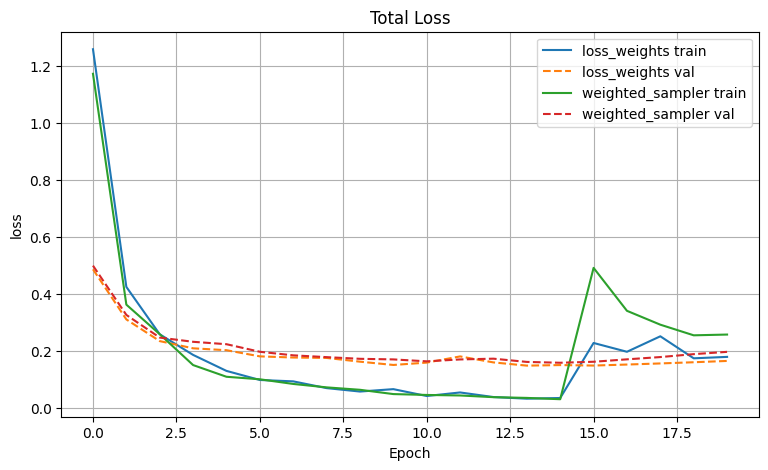

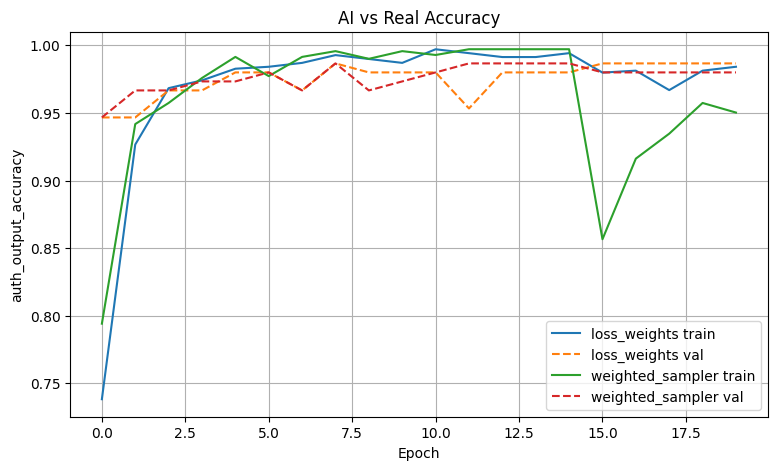

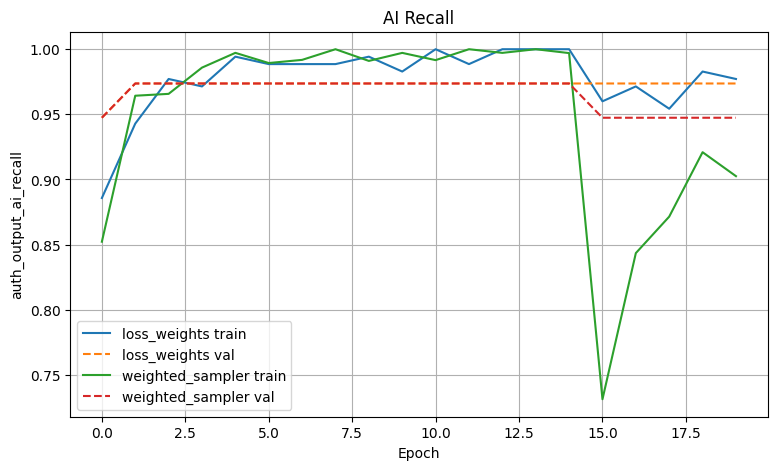

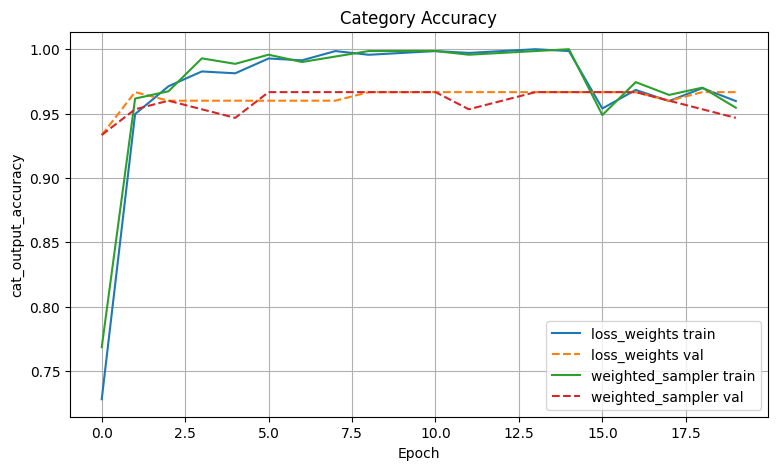

In [15]:
def collect_history(hist_list, metric_name):
    values = []
    for h in hist_list:
        if metric_name in h.history:
            values.extend(h.history[metric_name])
    return values


def plot_metric_for_strategies(histories_dict, metric_candidates, title):
    if isinstance(metric_candidates, str):
        metric_candidates = [metric_candidates]

    plt.figure(figsize=(9, 5))
    plotted = False

    for strategy, hist_list in histories_dict.items():
        used_metric = None
        values = []
        val_values = []

        for metric_name in metric_candidates:
            values = collect_history(hist_list, metric_name)
            val_values = collect_history(hist_list, "val_" + metric_name)
            if values or val_values:
                used_metric = metric_name
                break

        if values:
            plt.plot(values, label=f"{strategy} train")
            plotted = True
        if val_values:
            plt.plot(val_values, linestyle="--", label=f"{strategy} val")
            plotted = True

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(metric_candidates[0])
    if plotted:
        plt.legend()
    plt.grid(True)
    plt.show()

plot_metric_for_strategies(histories, "loss", "Total Loss")
plot_metric_for_strategies(histories, ["auth_output_accuracy", "auth_output_binary_accuracy"], "AI vs Real Accuracy")
plot_metric_for_strategies(histories, ["auth_output_ai_recall", "auth_output_recall"], "AI Recall")
plot_metric_for_strategies(histories, ["cat_output_accuracy", "cat_output_sparse_categorical_accuracy"], "Category Accuracy")

## 13. Evaluate on Test Set

In [16]:
def evaluate_model(model, strategy_name):
    print("=" * 80)
    print(f"Evaluation: {strategy_name}")
    print("=" * 80)

    test_results = model.evaluate(test_ds, return_dict=True, verbose=0)
    auth_probs, cat_probs = model.predict(test_ds, verbose=0)

    auth_probs = auth_probs.reshape(-1)
    auth_pred = (auth_probs >= 0.5).astype(int)
    cat_pred = np.argmax(cat_probs, axis=1)

    auth_true = test_df["auth_label"].values
    cat_true = test_df["cat_label"].values

    summary = {
        "strategy": strategy_name,
        "test_loss": test_results.get("loss", np.nan),
        "auth_accuracy": accuracy_score(auth_true, auth_pred),
        "auth_ai_recall": recall_score(auth_true, auth_pred, pos_label=1),
        "auth_macro_f1": f1_score(auth_true, auth_pred, average="macro"),
        "cat_accuracy": accuracy_score(cat_true, cat_pred),
        "cat_macro_f1": f1_score(cat_true, cat_pred, average="macro"),
    }

    try:
        summary["auth_auc"] = roc_auc_score(auth_true, auth_probs)
    except Exception:
        summary["auth_auc"] = np.nan

    print("\nAI vs Real Classification Report")
    print(classification_report(auth_true, auth_pred, target_names=["Real", "AI"], digits=4))

    print("Category Classification Report")
    print(classification_report(cat_true, cat_pred, target_names=category_encoder.classes_, digits=4))

    return summary, auth_probs, auth_pred, cat_pred

all_summaries = []
all_predictions = {}

for strategy_name, model in models.items():
    summary, auth_probs, auth_pred, cat_pred = evaluate_model(model, strategy_name)
    all_summaries.append(summary)
    all_predictions[strategy_name] = {
        "auth_probs": auth_probs,
        "auth_pred": auth_pred,
        "cat_pred": cat_pred,
    }

summary_df = pd.DataFrame(all_summaries).sort_values(
    by=["auth_ai_recall", "auth_macro_f1", "cat_macro_f1"],
    ascending=False,
)
summary_df

Evaluation: loss_weights

AI vs Real Classification Report
              precision    recall  f1-score   support

        Real     0.9910    0.9735    0.9821       113
          AI     0.9231    0.9730    0.9474        37

    accuracy                         0.9733       150
   macro avg     0.9570    0.9732    0.9648       150
weighted avg     0.9742    0.9733    0.9736       150

Category Classification Report
              precision    recall  f1-score   support

     animals     1.0000    1.0000    1.0000        30
        city     1.0000    1.0000    1.0000        30
        food     1.0000    1.0000    1.0000        30
      nature     1.0000    1.0000    1.0000        31
      people     1.0000    1.0000    1.0000        29

    accuracy                         1.0000       150
   macro avg     1.0000    1.0000    1.0000       150
weighted avg     1.0000    1.0000    1.0000       150

Evaluation: weighted_sampler

AI vs Real Classification Report
              precision    reca

,strategy,test_loss,auth_accuracy,auth_ai_recall,auth_macro_f1,cat_accuracy,cat_macro_f1,auth_auc
0,loss_weights,0.105704,0.973333,0.972973,0.964756,1.0,1.0,0.997608
1,weighted_sampler,0.084923,0.980000,0.945946,0.972844,1.0,1.0,0.997847


## 14. Confusion Matrices

The AI vs Real confusion matrix is especially important because the dataset is imbalanced. We focus on **AI recall**, meaning: among all true AI images, how many did the model correctly detect?

loss_weights


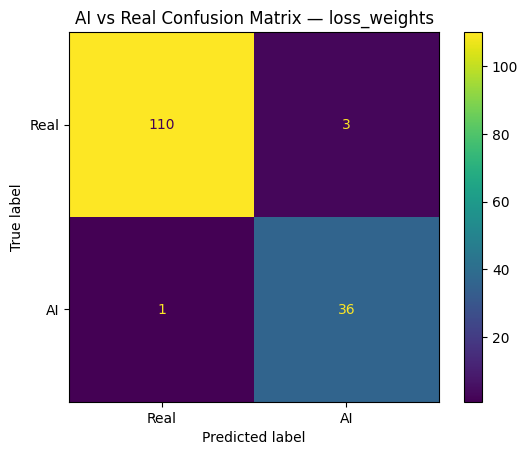

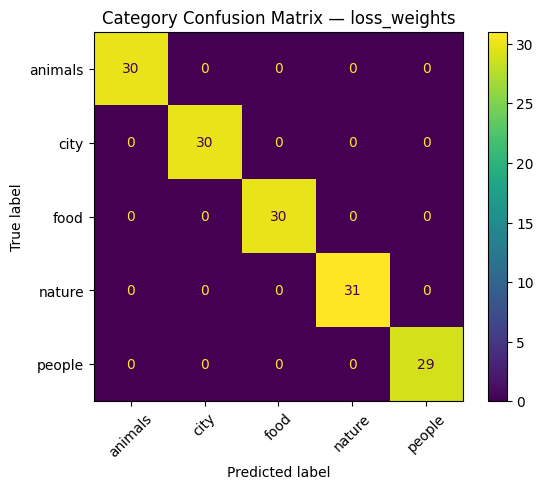

weighted_sampler


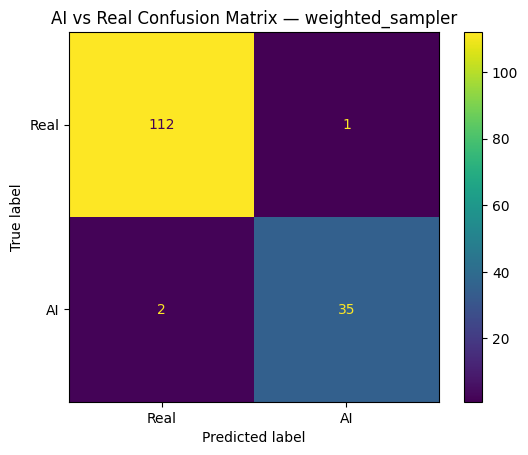

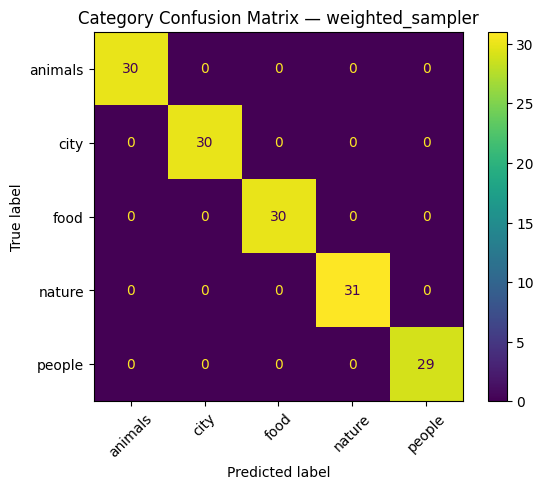

In [17]:
auth_true = test_df["auth_label"].values
cat_true = test_df["cat_label"].values

for strategy_name, preds in all_predictions.items():
    print("=" * 80)
    print(strategy_name)
    print("=" * 80)

    cm_auth = confusion_matrix(auth_true, preds["auth_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_auth, display_labels=["Real", "AI"])
    disp.plot(values_format="d")
    plt.title(f"AI vs Real Confusion Matrix — {strategy_name}")
    plt.show()

    cm_cat = confusion_matrix(cat_true, preds["cat_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_cat, display_labels=category_encoder.classes_)
    disp.plot(values_format="d", xticks_rotation=45)
    plt.title(f"Category Confusion Matrix — {strategy_name}")
    plt.show()

## 15. Inspect Misclassified Examples

In [18]:
# Choose the best strategy based on AI recall first, then macro F1.
best_strategy = summary_df.iloc[0]["strategy"]
print("Best strategy selected for error inspection:", best_strategy)

preds = all_predictions[best_strategy]
results_df = test_df.copy().reset_index(drop=True)
results_df["auth_prob_AI"] = preds["auth_probs"]
results_df["auth_pred"] = preds["auth_pred"]
results_df["auth_pred_name"] = np.where(results_df["auth_pred"] == 1, "AI", "Real")
results_df["cat_pred"] = preds["cat_pred"]
results_df["cat_pred_name"] = category_encoder.inverse_transform(preds["cat_pred"])
results_df["auth_correct"] = results_df["auth_label"] == results_df["auth_pred"]
results_df["cat_correct"] = results_df["cat_label"] == results_df["cat_pred"]

results_df.head()

Best strategy selected for error inspection: loss_weights


,filepath,label,authenticity,auth_label,category,cat_label,strat_key,auth_prob_AI,auth_pred,auth_pred_name,cat_pred,cat_pred_name,auth_correct,cat_correct
0,/kaggle/input/ai-vs-real-images-dataset/real_d...,Real,Real,0,animals,0,Real_animals,0.242866,0,Real,0,animals,True,True
1,/kaggle/input/ai-vs-real-images-dataset/Ai_gen...,AI,AI,1,nature,3,AI_nature,0.988551,1,AI,3,nature,True,True
2,/kaggle/input/ai-vs-real-images-dataset/real_d...,Real,Real,0,people,4,Real_people,0.000026,0,Real,4,people,True,True
3,/kaggle/input/ai-vs-real-images-dataset/Ai_gen...,AI,AI,1,nature,3,AI_nature,0.999955,1,AI,3,nature,True,True
4,/kaggle/input/ai-vs-real-images-dataset/Ai_gen...,AI,AI,1,animals,0,AI_animals,0.999874,1,AI,0,animals,True,True


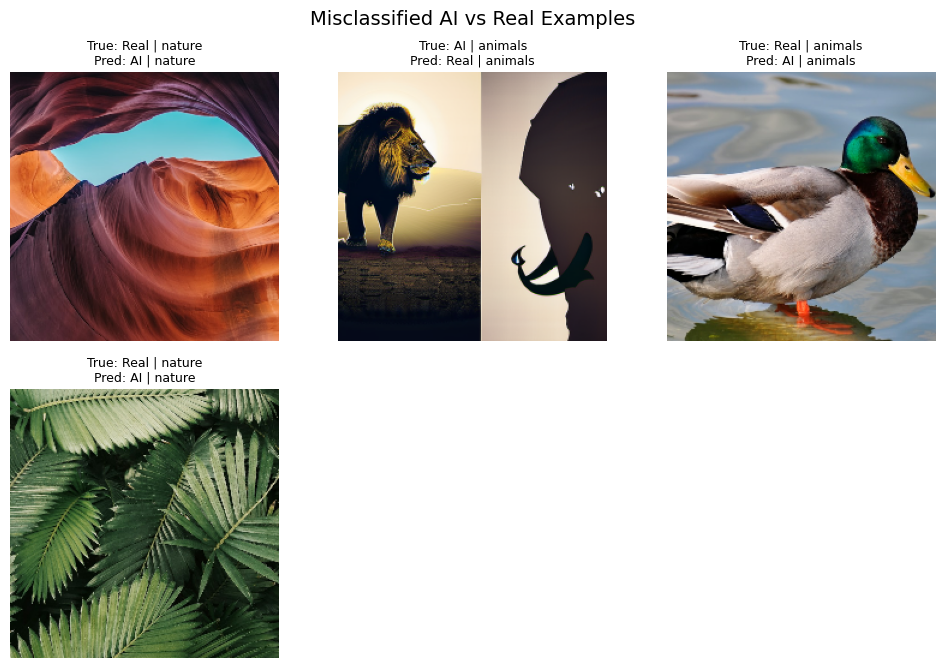

No examples to show.


In [19]:
def load_display_image(filepath):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.cast(image, tf.float32)
    image = resize_shortest_side(image, RESIZE_SIZE)
    image = center_crop_224(image)
    return image.numpy().astype("uint8")


def show_examples(example_df, title, n=9):
    if len(example_df) == 0:
        print("No examples to show.")
        return
    sample_df = example_df.sample(min(n, len(example_df)), random_state=SEED)

    plt.figure(figsize=(10, 10))
    for i, (_, row) in enumerate(sample_df.iterrows()):
        image = load_display_image(row["filepath"])
        plt.subplot(3, 3, i + 1)
        plt.imshow(image)
        plt.title(
            f"True: {row['label']} | {row['category']}\n"
            f"Pred: {row['auth_pred_name']} | {row['cat_pred_name']}",
            fontsize=9,
        )
        plt.axis("off")
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

show_examples(results_df[~results_df["auth_correct"]], "Misclassified AI vs Real Examples")
show_examples(results_df[~results_df["cat_correct"]], "Misclassified Category Examples")

## 16. Save Splits, Models, Metrics, and Predictions

In [20]:
OUTPUT_DIR = Path("./multitask_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(OUTPUT_DIR / "train_split.csv", index=False)
val_df.to_csv(OUTPUT_DIR / "val_split.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test_split.csv", index=False)
summary_df.to_csv(OUTPUT_DIR / "strategy_comparison_metrics.csv", index=False)
results_df.to_csv(OUTPUT_DIR / "best_strategy_test_predictions.csv", index=False)

for strategy_name, model in models.items():
    model.save(OUTPUT_DIR / f"multitask_efficientnetb0_{strategy_name}.keras")

print("Saved outputs to:", OUTPUT_DIR.resolve())
print("Saved strategies:", list(models.keys()))

Saved outputs to: /content/multitask_outputs
Saved strategies: ['loss_weights', 'weighted_sampler']


In [21]:
print("Train unique files:", train_df["filepath"].nunique(), len(train_df))
print("Val unique files:", val_df["filepath"].nunique(), len(val_df))
print("Test unique files:", test_df["filepath"].nunique(), len(test_df))

overlap_train_val = set(train_df["filepath"]) & set(val_df["filepath"])
overlap_train_test = set(train_df["filepath"]) & set(test_df["filepath"])
overlap_val_test = set(val_df["filepath"]) & set(test_df["filepath"])

print("Train-Val overlap:", len(overlap_train_val))
print("Train-Test overlap:", len(overlap_train_test))
print("Val-Test overlap:", len(overlap_val_test))

Train unique files: 695 695
Val unique files: 150 150
Test unique files: 150 150
Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [23]:
from PIL import Image
import imagehash

def get_image_hash(path):
    try:
        return str(imagehash.phash(Image.open(path).convert("RGB")))
    except Exception:
        return None

train_hashes = set(train_df["filepath"].apply(get_image_hash))
val_hashes = set(val_df["filepath"].apply(get_image_hash))
test_hashes = set(test_df["filepath"].apply(get_image_hash))

print("Train-Val duplicate hashes:", len(train_hashes & val_hashes))
print("Train-Test duplicate hashes:", len(train_hashes & test_hashes))
print("Val-Test duplicate hashes:", len(val_hashes & test_hashes))

Train-Val duplicate hashes: 0
Train-Test duplicate hashes: 0
Val-Test duplicate hashes: 0


In [24]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
